UCI Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      193             72             25      169  23.722020   
1      200            107             40       48  39.019181   
2      165             59             26      165  38.047034   
3      152            101             10      300  44.676570   
4      171             85             27      108  29.709714   

   DiabetesPedigreeFunction  Age  Outcome  
0                  0.287041   42        0  
1                  1.276820   26        0  
2                  1.303484   37        0  
3                  0.370960   25        0  
4                  0.520054   39        0  

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      145             67             39       39  45.000000   
1      101             75             12       15  29.082089   
2      147             87             50       84  32.060206   
3       80             66  

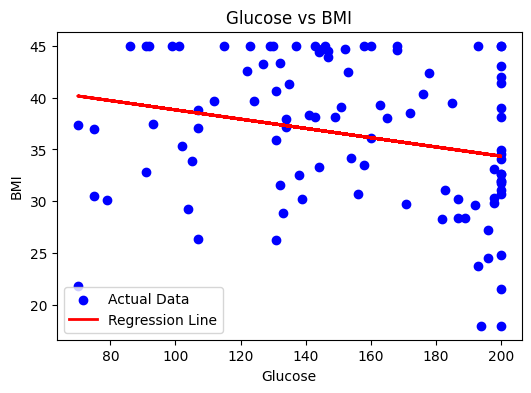


Linear Regression (Glucose -> BMI)
R2 Score: 0.0377


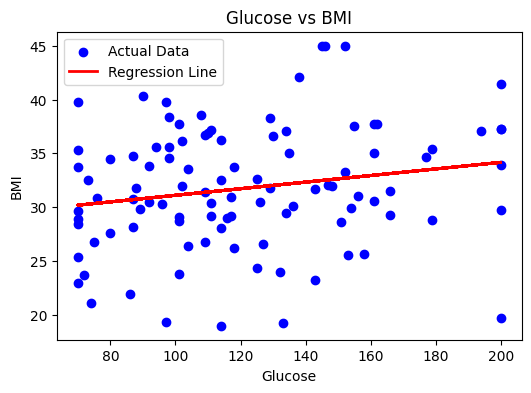


UCI Diabetes Dataset

Logistic Regression
Accuracy Score: 0.6

Pima Indians Diabetes Dataset

Logistic Regression
Accuracy Score: 0.5


In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load the Datasets
uci_diabetes = pd.read_csv('/content/uci_diabetes.csv')
pima_diabetes = pd.read_csv('/content/pima_diabetes.csv')

# Display Dataset Samples
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# -----------------------------
# Linear Regression
# -----------------------------
def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression ({x_column} -> {y_column})")
    print("R2 Score:", round(r2,4))

    plt.figure(figsize=(6,4))
    plt.scatter(X, Y, color='blue', label='Actual Data')
    plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.legend()
    plt.show()

# Apply Linear Regression
linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

# -----------------------------
# Logistic Regression
# -----------------------------
def logistic_regression_analysis(df):

    features = ["Glucose","BloodPressure","BMI","Age"]

    X = df[features]
    Y = df["Outcome"]

    X_train,X_test,Y_train,Y_test = train_test_split(
        X,Y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train,Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test,Y_pred)

    print("\nLogistic Regression")
    print("Accuracy Score:", round(accuracy,4))

# Apply Logistic Regression
print("\nUCI Diabetes Dataset")
logistic_regression_analysis(uci_diabetes)

print("\nPima Indians Diabetes Dataset")
logistic_regression_analysis(pima_diabetes)